<h1>1. MA<h1>


In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

In [2]:
symbol = 'AAPL'
start_date = '2015-01-01' 
end_date = '2022-12-31' 
data = yf.download(symbol, start=start_date, end=end_date)

[*********************100%***********************]  1 of 1 completed


In [3]:
spy_data = yf.download('SPY', start=start_date, end=end_date)
spy_data['Daily_Return'] = spy_data['Close'].pct_change() 
spy_data['Cumulative_Return'] = (1 + spy_data['Daily_Return']).cumprod()

[*********************100%***********************]  1 of 1 completed


In [4]:
data['SMA_50'] = data['Close'].rolling(window=50).mean()
data['Signal'] = np.where(data['Close'] > data['SMA_50'], 1, 0)

In [5]:
data['Daily_Return'] = data['Close'].pct_change() 
data['Strategy_Return'] = data['Daily_Return'] * data['Signal'].shift(1) 
data['Cumulative_Return'] = (1 + data['Strategy_Return']).cumprod()

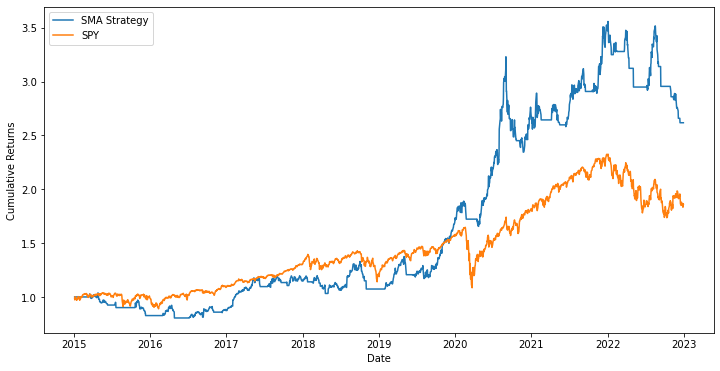

In [6]:
plt.figure(figsize=(12, 6)) 
plt.plot(data.index, data['Cumulative_Return'], label='SMA Strategy') 
plt.plot(spy_data.index, spy_data['Cumulative_Return'], label='SPY') 
plt.xlabel('Date') 
plt.ylabel('Cumulative Returns') 
plt.legend() 
plt.show()

<h1>2. RSI<h1>

In [7]:
def rsi(data, period): 
    delta = data.diff().dropna() 
    gain = delta.where(delta > 0, 0) 
    loss = -delta.where(delta < 0, 0) 
    avg_gain = gain.rolling(window=period).mean() 
    avg_loss = loss.rolling(window=period).mean() 
    rs = avg_gain / avg_loss
    return 100 - (100 / (1 + rs)) 

In [8]:
data['RSI'] = rsi(data['Close'], 14)

In [9]:
data['Signal_rsi'] = 0 
data.loc[data['RSI'] < 30, 'Signal_rsi'] = 1 
data.loc[data['RSI'] > 70, 'Signal_rsi'] = -1

In [10]:
data['Strategy_Return_rsi'] = data['Daily_Return'] * data['Signal_rsi'].shift(1)
data['Cumulative_Return_rsi'] = (1 + data['Strategy_Return_rsi']).cumprod()

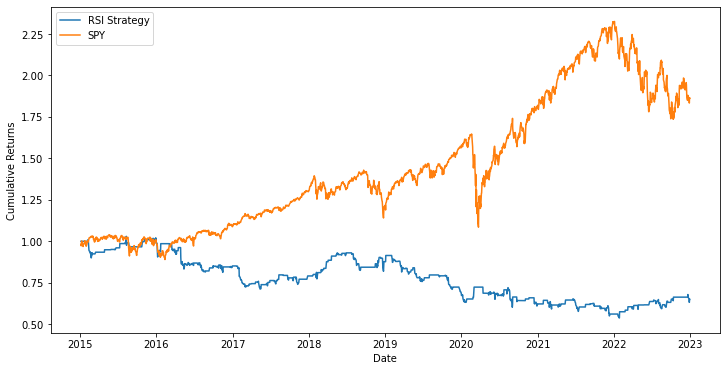

In [11]:
plt.figure(figsize=(12, 6)) 
plt.plot(data.index, data['Cumulative_Return_rsi'], label='RSI Strategy') 
plt.plot(spy_data.index, spy_data['Cumulative_Return'], label='SPY') 
plt.xlabel('Date') 
plt.ylabel('Cumulative Returns') 
plt.legend() 
plt.show()

Compared to MA, PSI indicator performs worse, even worse than S&P. The main reason is that the overbought and oversold assets do not necessarily turn around right away.
The RSI is a very useful tool but is not a great stand-alone indicator. Most technicians view the RSI as a confirming indicator.
See Rocky Whie https://www.moneyshow.com/articles/tebiwkly08-52167/trading-the-relative-strength-index-rsi-does-it-work/